# The Guide to Inferential Statistics in Python

This notebook covers the complete workflow for inferential statistics, from basic T-tests to advanced modeling and survival analysis.

**Table of Contents:**
1.  **Setup:** Data Generation (Continuous, Categorical, Time-to-Event).
2.  **Descriptive Stats:** Normality Checks (The Bell Curve).
3.  **Comparison of Means:**
    * One-Sample Tests (vs Known Value)
    * Two Independent Groups (T-Test / Mann-Whitney) + **Effect Size (Cohen's d)**
    * Paired Groups (Before vs After)
4.  **Analysis of Variance (ANOVA):**
    * One-Way ANOVA + **Post-Hoc Testing (Tukey's HSD)**
    * **Two-Way ANOVA** (Interaction Effects)
5.  **Regression & Classification:**
    * Linear Regression (Predicting Values)
    * **Logistic Regression** (Predicting Probabilities/Categories)
6.  **Categorical Analysis:** Chi-Square Test.
7.  **Planning:** **Power Analysis** (Sample Size Calculation).
8.  **Time-to-Event:** **Survival Analysis** (Kaplan-Meier).

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.multicomp as mc # For Tukey Post-Hoc
from statsmodels.formula.api import ols, logit # For ANOVA/Logistic
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
np.random.seed(42)

# --- Generate Comprehensive Mock Data ---
N = 200
data = pd.DataFrame({
    # Continuous Data (Normal & Skewed)
    'group_a': np.random.normal(loc=50, scale=10, size=N),
    'group_b': np.random.normal(loc=55, scale=10, size=N),
    'group_c': np.random.normal(loc=42, scale=12, size=N),
    'skewed_data': np.random.exponential(scale=10, size=N),
    
    # Paired Data
    'bp_before': np.random.normal(loc=120, scale=10, size=N),
    'bp_after': np.random.normal(loc=115, scale=10, size=N),
    
    # Regression Data
    'experience_yrs': np.random.uniform(1, 20, size=N),
    
    # Logistic Regression Data (Study Hours -> Pass/Fail)
    'study_hours': np.random.uniform(1, 15, size=N),
    
    # Factors for ANOVA
    'teaching_method': np.random.choice(['Online', 'In-Person'], size=N),
    'classroom': np.random.choice(['Room A', 'Room B', 'Room C'], size=N),
    
    # Survival Analysis Data (Time to Event)
    'months_subscribed': np.random.exponential(scale=12, size=N), # Time
    'churn_event': np.random.binomial(1, 0.7, size=N) # 1=Churned, 0=Still Subscribed
})

# Feature Engineering
# 1. Linear relationship for Salary
data['salary'] = 40000 + (data['experience_yrs'] * 3000) + np.random.normal(0, 5000, N)

# 2. Logistic relationship for Pass/Fail (Sigmoid)
log_odds = -5 + (0.8 * data['study_hours'])
prob_pass = 1 / (1 + np.exp(-log_odds))
data['passed_exam'] = np.random.binomial(1, prob_pass) # 1=Pass, 0=Fail

print("Complex Dataset Generated Successfully.")
display(data.head())

Complex Dataset Generated Successfully.


,group_a,group_b,group_c,skewed_data,bp_before,bp_after,experience_yrs,study_hours,teaching_method,classroom,months_subscribed,churn_event,salary,passed_exam
0,54.967142,58.577874,22.866868,2.603930,114.243622,121.427228,10.862554,14.521510,In-Person,Room C,4.220075,1,74921.289091,1
1,48.617357,60.607845,34.807500,12.810431,121.220098,128.291525,10.104456,7.054970,In-Person,Room C,30.042910,0,72743.178440,0
2,56.476885,65.830512,42.062924,12.730962,145.600845,116.965212,1.487199,5.365426,In-Person,Room C,1.408501,1,46207.460453,0
3,65.230299,65.538021,42.563767,10.248442,119.039401,122.090038,7.483709,8.085986,In-Person,Room B,17.104535,1,65806.311238,1
4,47.658466,41.223306,36.599214,11.840017,131.492733,114.102643,8.223717,7.153164,In-Person,Room B,53.139930,0,63558.441091,1


---
### 1. Descriptive Statistics & Normality Checks

Before running statistical tests, we must check the **Normality Assumption**. Parametric tests (like T-Tests and ANOVA) assume the data follows a "Bell Curve" (Normal Distribution). If the data is skewed or has heavy outliers, we must use Non-Parametric equivalents.

To determine this, we run a battery of **four different normality tests**, as each has its own strengths depending on the dataset:

1. **Shapiro-Wilk Test**
   * **Best for:** Small to Medium samples ($N < 5000$).
   * **Details:** This is the "gold standard" and the most rigorous test for normality. However, it can be *too* sensitive for massive datasets.
2. **D'Agostino's $K^2$ Test**
   * **Best for:** Large samples ($N > 5000$).
   * **Details:** Evaluates the distribution's skewness (asymmetry) and kurtosis (tailedness) to determine if it matches a bell curve. Safer for Big Data.
3. **Kolmogorov-Smirnov (K-S) Test**
   * **Best for:** Comparing a sample to a theoretical reference distribution.
   * **Details:** Historically very common, though generally considered less powerful than Shapiro-Wilk. 
4. **Anderson-Darling Test**
   * **Best for:** Detecting deviations in the "tails" (extreme values) of the data.
   * **Details:** Often used in risk management or finance where outliers are highly impactful. It uses critical values rather than a standard p-value.

### General Rule for Interpretation:
For tests 1, 2, and 3, we look at the **P-value**:
* **$p > 0.05$:** Fail to reject the Null Hypothesis. The data **IS Normal** (Proceed with Parametric tests).
* **$p < 0.05$:** Reject the Null Hypothesis. The data is **NOT Normal** (Proceed with Non-Parametric tests).

--- Comprehensive Normality Check for: Group A (Normal) (N=200) ---
1. Shapiro-Wilk:      p=0.82899 [Normal (Use Parametric)]
2. D'Agostino's K^2:  p=0.71307 [Normal]
3. Kolmogorov-Smirnov:p=0.92160 [Normal]
4. Anderson-Darling:  Statistic=0.275
   At 5.0% level:     Normal (Stat 0.275 < CV 0.749)


C:\Users\ACER SWIFT 3\AppData\Local\Temp\ipykernel_14080\3864521752.py:19: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(data, dist='norm')


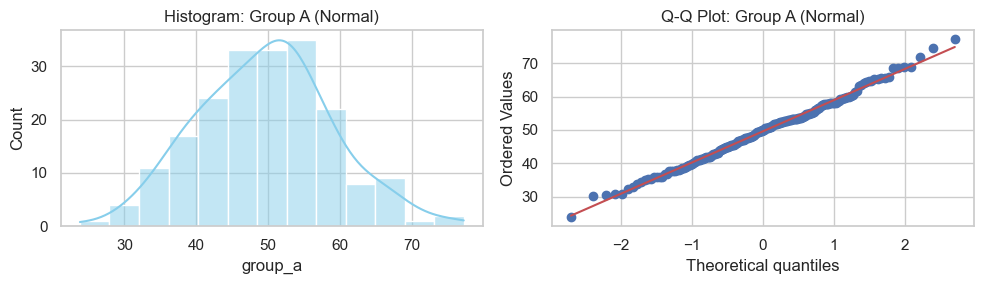



--- Comprehensive Normality Check for: Exponential Data (Skewed) (N=200) ---
1. Shapiro-Wilk:      p=0.00000 [NOT Normal (Use Non-Parametric)]
2. D'Agostino's K^2:  p=0.00000 [NOT Normal]
3. Kolmogorov-Smirnov:p=0.00006 [NOT Normal]
4. Anderson-Darling:  Statistic=9.944
   At 5.0% level:     NOT Normal (Stat 9.944 > CV 0.749)


C:\Users\ACER SWIFT 3\AppData\Local\Temp\ipykernel_14080\3864521752.py:19: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(data, dist='norm')


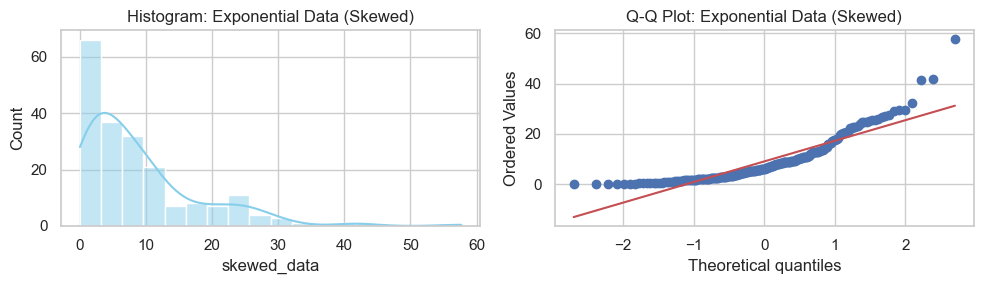

In [10]:
def check_normality(data, name):
    print(f"--- Comprehensive Normality Check for: {name} (N={len(data)}) ---")
    
    # --- 1. Statistical Tests ---
    # Shapiro-Wilk (Best for N < 5000)
    stat_s, p_shapiro = stats.shapiro(data)
    print(f"1. Shapiro-Wilk:      p={p_shapiro:.5f} [{'Normal (Use Parametric)' if p_shapiro>0.05 else 'NOT Normal (Use Non-Parametric)'}]")

    # D'Agostino's K^2 (Best for N > 5000)
    stat_k, p_agostino = stats.normaltest(data)
    print(f"2. D'Agostino's K^2:  p={p_agostino:.5f} [{'Normal' if p_agostino>0.05 else 'NOT Normal'}]")

    # Kolmogorov-Smirnov
    loc, scale = np.mean(data), np.std(data)
    stat_ks, p_ks = stats.kstest(data, 'norm', args=(loc, scale))
    print(f"3. Kolmogorov-Smirnov:p={p_ks:.5f} [{'Normal' if p_ks>0.05 else 'NOT Normal'}]")
    
    # Anderson-Darling (Focuses on tails/outliers)
    result = stats.anderson(data, dist='norm')
    # Let's extract just the 5% significance level for a clean summary
    sig_index = 2 # Index 2 corresponds to the 5.0% significance level in SciPy
    cv = result.critical_values[sig_index]
    print(f"4. Anderson-Darling:  Statistic={result.statistic:.3f}")
    if result.statistic < cv:
        print(f"   At 5.0% level:     Normal (Stat {result.statistic:.3f} < CV {cv:.3f})")
    else:
        print(f"   At 5.0% level:     NOT Normal (Stat {result.statistic:.3f} > CV {cv:.3f})")

    # --- 2. Visual Checks ---
    plt.figure(figsize=(10, 3))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True, color='skyblue')
    plt.title(f'Histogram: {name}')
    
    # Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: {name}')
    
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60 + "\n")

# --- Run on our Mock Data ---
check_normality(data['group_a'], "Group A (Normal)")
check_normality(data['skewed_data'], "Exponential Data (Skewed)")

---
### 2. Comparison of Means & Effect Size

When comparing groups, we need two pieces of information to make a decision: **Significance** (is the result real?) and **Magnitude** (is the result important?).

a. **The P-Value (Significance)**
The **P-Value** tests the Null Hypothesis ($H_0$), which usually states "There is NO difference between the groups."
* **$p < 0.05$ (Significant):** We reject the null hypothesis. There is likely a real difference.
* **$p > 0.05$ (Not Significant):** We fail to reject the null hypothesis. Any observed difference could just be random chance.

b. **Cohen's d (Effect Size)**
While the p-value tells you *if* a difference exists, **Cohen's d** tells you *how big* that difference is in standardized units.
* **Small effect:** ~0.2
* **Medium effect:** ~0.5
* **Large effect:** ~0.8+

*Note: You can have a "significant" result (p < 0.05) that is actually tiny and unimportant (small Effect Size) if your sample size is huge.*

Independent T-Test: p-value = 0.00000
Cohen's d (Effect Size): -0.655
Interpretation: Medium Effect


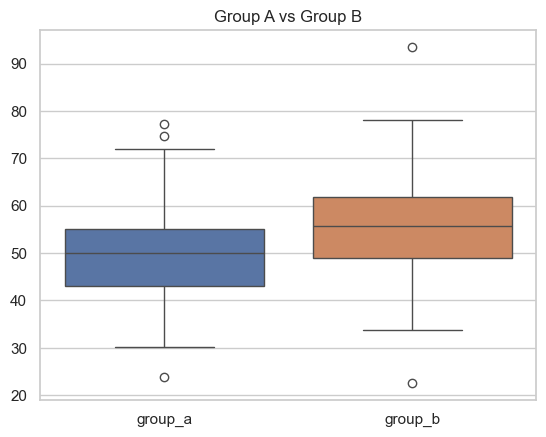

In [3]:
# --- 1. Independent T-Test ---
t_stat, p_val = stats.ttest_ind(data['group_a'], data['group_b'])

# --- 2. Calculate Cohen's d (Effect Size) ---
mean_diff = np.mean(data['group_a']) - np.mean(data['group_b'])
pooled_std = np.sqrt((np.std(data['group_a'])**2 + np.std(data['group_b'])**2) / 2)
cohens_d = mean_diff / pooled_std

print(f"Independent T-Test: p-value = {p_val:.5f}")
print(f"Cohen's d (Effect Size): {cohens_d:.3f}")
if abs(cohens_d) > 0.8: print("Interpretation: Large Effect")
elif abs(cohens_d) > 0.5: print("Interpretation: Medium Effect")
else: print("Interpretation: Small Effect")

# Visual
sns.boxplot(data=data[['group_a', 'group_b']])
plt.title("Group A vs Group B")
plt.show()

---
### 3. ANOVA & Post-Hoc Tests
**One-Way ANOVA** tells us if *at least one* group is different.
**Tukey's HSD (Post-Hoc)** tells us exactly *which* groups differ.

**Two-Way ANOVA** tests two factors at once (e.g., Classroom AND Teaching Method) and their interaction.

**Effect Size in ANOVA: Eta-Squared ($\eta^2$)**
Just as Cohen's d measures effect size for T-Tests, **Eta-Squared ($\eta^2$)** measures effect size for ANOVA. It tells us the **proportion of variance** in the dependent variable (the score) that is explained by the independent variable (the groups/factors).

* **Small effect:** ~0.01 (1% of variance explained)
* **Medium effect:** ~0.06 (6% of variance explained)
* **Large effect:** ~0.14+ (14% or more of variance explained)

In [16]:
print("--- 1. One-Way ANOVA & Effect Size ---")
# One-Way ANOVA
f_stat, p_val = stats.f_oneway(data['group_a'], data['group_b'], data['group_c'])
print(f"ANOVA p-value: {p_val:.5f} (Significant difference exists)")

# Calculate Eta-Squared for One-Way ANOVA
# Formula: eta_sq = (F * df_between) / (F * df_between + df_within)
k = 3  # Number of groups
N = len(data['group_a']) + len(data['group_b']) + len(data['group_c']) # Total samples
df_between = k - 1
df_within = N - k

eta_sq = (f_stat * df_between) / ((f_stat * df_between) + df_within)
print(f"Effect Size (Eta-Squared): {eta_sq:.3f}")
if eta_sq < 0.01: print("Interpretation: Negligible Effect")
elif eta_sq < 0.06: print("Interpretation: Small Effect")
elif eta_sq < 0.14: print("Interpretation: Medium Effect")
else: print("Interpretation: Large Effect")


print("\n--- 2. Tukey's HSD Post-Hoc Test ---")
# Melt data for statsmodels
melted = pd.melt(data[['group_a', 'group_b', 'group_c']], var_name='Group', value_name='Score')
tukey = mc.MultiComparison(melted['Score'], melted['Group'])
tukey_result = tukey.tukeyhsd()
print(tukey_result)


print("\n--- 3. Two-Way ANOVA (Interaction Effects) & Eta-Squared ---")
# Does score depend on Classroom AND Teaching Method?
# Model: Score ~ C(Classroom) + C(Method) + C(Classroom):C(Method)
model = ols('group_a ~ C(classroom) + C(teaching_method) + C(classroom):C(teaching_method)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Calculate Eta-Squared for Two-Way ANOVA
# Formula: SS_factor / SS_total
ss_total = anova_table['sum_sq'].sum()
anova_table['eta_sq'] = anova_table['sum_sq'] / ss_total

print(anova_table)
print("\n(Note: 'eta_sq' column shows the proportion of variance explained by each factor)")

--- 1. One-Way ANOVA & Effect Size ---
ANOVA p-value: 0.00000 (Significant difference exists)
Effect Size (Eta-Squared): 0.256
Interpretation: Large Effect

--- 2. Tukey's HSD Post-Hoc Test ---
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj  lower    upper   reject
-------------------------------------------------------
group_a group_b   6.2664   0.0   3.8157   8.7171   True
group_a group_c  -8.6202   0.0 -11.0709  -6.1694   True
group_b group_c -14.8865   0.0 -17.3373 -12.4358   True
-------------------------------------------------------

--- 3. Two-Way ANOVA (Interaction Effects) & Eta-Squared ---
                                       sum_sq     df         F    PR(>F)  \
C(classroom)                        78.273336    2.0  0.444622  0.641718   
C(teaching_method)                  90.586371    1.0  1.029130  0.311627   
C(classroom):C(teaching_method)     13.475248    2.0  0.076545  0.926340   
Residual                         17076.322168  1

---
### 4. Regression & Classification
**Linear Regression:** Predicts a continuous value (Salary).
**Logistic Regression:** Predicts a binary category (Pass/Fail). This is crucial for classification problems.

Linear Regression R-squared: 0.921


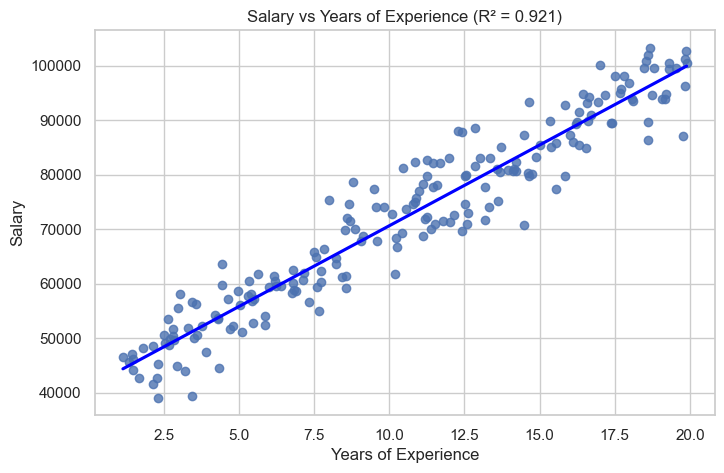


--- Logistic Regression Summary ---
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1953      0.774     -6.713      0.000      -6.712      -3.678
study_hours     0.8124      0.112      7.228      0.000       0.592       1.033


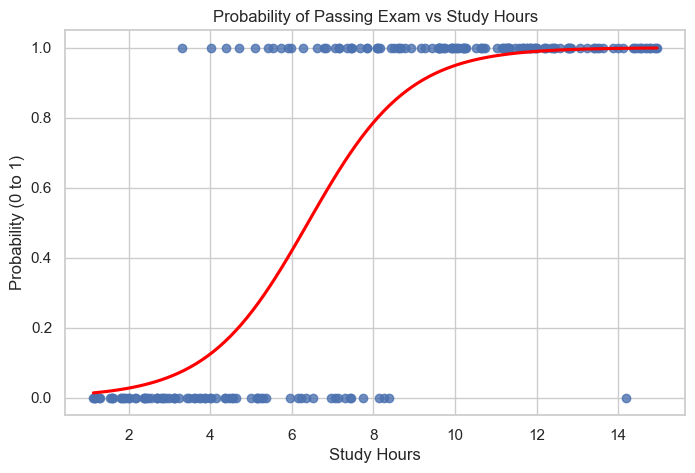

In [9]:
# --- Linear Regression (Salary Prediction) ---
slope, intercept, r_value, _, _ = stats.linregress(data['experience_yrs'], data['salary'])
print(f"Linear Regression R-squared: {r_value**2:.3f}")

# Visualizing the Linear Regression
plt.figure(figsize=(8, 5))
sns.regplot(x='experience_yrs', y='salary', data=data, ci=None, line_kws={'color': 'blue'})
plt.title(f"Salary vs Years of Experience (R² = {r_value**2:.3f})")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()


# --- Logistic Regression (Pass/Fail Prediction) ---
# Predicting 'passed_exam' (0 or 1) using 'study_hours'
log_reg = sm.Logit(data['passed_exam'], sm.add_constant(data['study_hours'])).fit(disp=0)

print("\n--- Logistic Regression Summary ---")
print(log_reg.summary().tables[1])

# Visualizing the Sigmoid Curve
plt.figure(figsize=(8, 5))
sns.regplot(x='study_hours', y='passed_exam', data=data, logistic=True, ci=None, line_kws={'color': 'red'})
plt.title("Probability of Passing Exam vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Probability (0 to 1)")
plt.show()

---
### 5. Power Analysis (Sample Size Calculation)
Before running a study, we must ask: "How many samples do I need?"
* **Alpha:** 0.05 (Standard significance level)
* **Power:** 0.80 (Standard probability of detecting an effect if it exists)
* **Effect Size:** Expected magnitude of difference.

--- Sample Size Calculation ---
To detect a medium effect (0.5) with 80% power, you need:
64 observations per group.


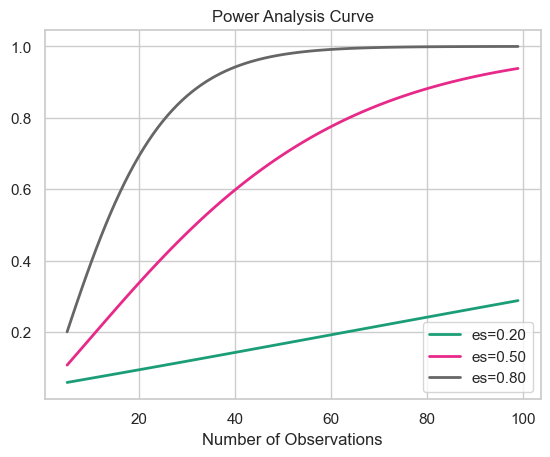

In [6]:
from statsmodels.stats.power import TTestIndPower

# Parameters
effect_size = 0.5  # Medium effect
alpha = 0.05       # 5% chance of false positive
power = 0.80       # 80% chance of detecting the effect

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha)

print(f"--- Sample Size Calculation ---")
print(f"To detect a medium effect (0.5) with 80% power, you need:")
print(f"{int(np.ceil(sample_size))} observations per group.")

# Plot Power Curve
analysis.plot_power(dep_var='nobs', nobs=np.arange(5, 100), effect_size=np.array([0.2, 0.5, 0.8]))
plt.title("Power Analysis Curve")
plt.show()

---
### 6. Survival Analysis (Time-to-Event)
Used when the outcome is **"Time until an event"** (e.g., Customer Churn, Machine Failure).

* **Kaplan-Meier Estimator:** Visualizes the overall survival probability over time.
* **Cox Proportional Hazards (Cox PH):** Evaluates how different variables (covariates) impact the *hazard rate* (the risk of the event happening). 
  * *Hazard Ratio (HR) > 1:* Variable increases risk of the event.
  * *Hazard Ratio (HR) < 1:* Variable decreases risk of the event (protective).

<Figure size 800x500 with 0 Axes>

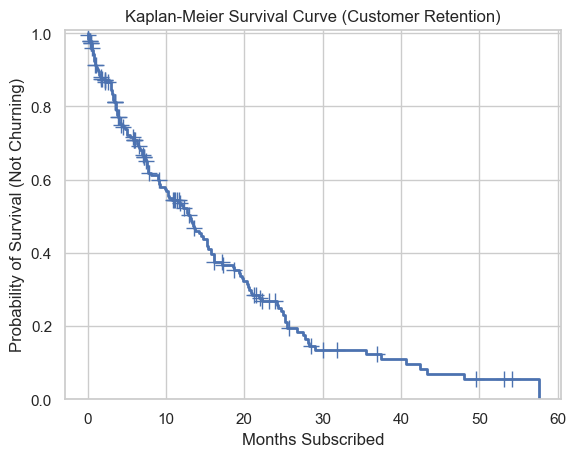

Median Survival Time: 13.0 months


In [12]:
# Note: For professional survival analysis, 'lifelines' library is recommended.
# Here we use statsmodels to keep dependencies standard.

from statsmodels.duration.survfunc import SurvfuncRight

# 'months_subscribed' is time, 'churn_event' is the event (1=Churned, 0=Censored/Active)
surv = SurvfuncRight(data['months_subscribed'], data['churn_event'])

# Plot
plt.figure(figsize=(8, 5))
surv.plot()
plt.title("Kaplan-Meier Survival Curve (Customer Retention)")
plt.xlabel("Months Subscribed")
plt.ylabel("Probability of Survival (Not Churning)")
plt.grid(True)
plt.show()

print(f"Median Survival Time: {surv.quantile(0.5):.1f} months")

--- 1. Kaplan-Meier Estimator (Overall Survival) ---


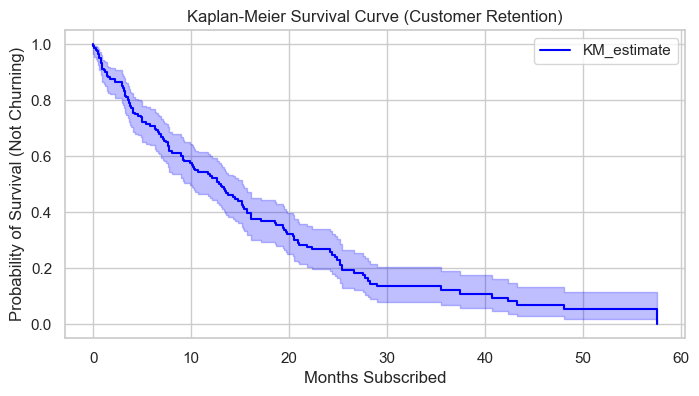

Median Survival Time: 13.0 months

--- 2. Cox Proportional Hazards Model (Impact of Covariates) ---


<lifelines.CoxPHFitter: fitted with 200 total observations, 60 right-censored observations>
             duration col = 'months_subscribed'
                event col = 'churn_event'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 140
   partial log-likelihood = -605.43
         time fit was run = 2026-02-23 04:00:52 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
experience_yrs  0.02      1.03      0.02           -0.01            0.06                0.99                1.06
study_hours     0.00      1.00      0.02           -0.04            0.04                0.96                1.04

                cmp to    z    p  -log2(p)
covariate                                 
experience_yrs    0.00 1.57 0.12      3.11
study_hours       0.00 0.04 0.97      0.05
---
Concordance = 0.55
Partial AIC = 1214.86
log-likelihood ratio test = 2.49 on 2 df
-log2(p) of ll-ratio test = 1.80

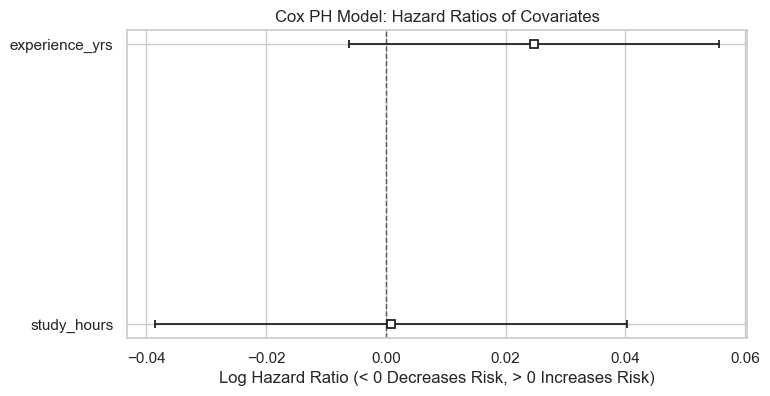

In [13]:
from lifelines import KaplanMeierFitter, CoxPHFitter

print("--- 1. Kaplan-Meier Estimator (Overall Survival) ---")
kmf = KaplanMeierFitter()

# Fit data: 'months_subscribed' is time, 'churn_event' is the event (1=Churned, 0=Active)
kmf.fit(durations=data['months_subscribed'], event_observed=data['churn_event'])

plt.figure(figsize=(8, 4))
kmf.plot_survival_function(color='blue')
plt.title("Kaplan-Meier Survival Curve (Customer Retention)")
plt.xlabel("Months Subscribed")
plt.ylabel("Probability of Survival (Not Churning)")
plt.grid(True)
plt.show()

print(f"Median Survival Time: {kmf.median_survival_time_:.1f} months\n")


print("--- 2. Cox Proportional Hazards Model (Impact of Covariates) ---")
# To run Cox PH, we prepare a DataFrame with the time, event, and the predictors we want to test
# Let's see if 'experience_yrs' and 'study_hours' affect the risk of churning
df_cox = data[['months_subscribed', 'churn_event', 'experience_yrs', 'study_hours']]

cph = CoxPHFitter()
cph.fit(df_cox, duration_col='months_subscribed', event_col='churn_event')

# Print the statistical summary
cph.print_summary()

# Visualize the Hazard Ratios
plt.figure(figsize=(8, 4))
cph.plot()
plt.title("Cox PH Model: Hazard Ratios of Covariates")
plt.xlabel("Log Hazard Ratio (< 0 Decreases Risk, > 0 Increases Risk)")
plt.show()